In [1]:
import torch
from dataset.climatenet import ClimateDataset 
data_dir = "../data/"
train_dataset = ClimateDataset(
        data_dir=data_dir, train_flag=True, transforms=None
    )

Loading mean/std from ../data/mean_std.npy
AR Ratio (negative/positive): 16.982505712876822, TC Ratio: 257.2420611525207


In [13]:
import numpy as np

ar_masks_per_image = []
tc_masks_per_image = []
ar_pixels_per_image = []
tc_pixels_per_image = []
ar_bg_obj_ratios = []
tc_bg_obj_ratios = []

for i in range(len(train_dataset)):
    # Get AR and TC object masks
    ar_masks = train_dataset[i]['ar_object_masks']
    tc_masks = train_dataset[i]['tc_object_masks']

    # Handle None cases
    if ar_masks is None:
        num_ar_masks = 0
        ar_pixels = []
        ar_bg_obj_ratio = []
    else:
        num_ar_masks = ar_masks.shape[0]
        ar_pixels = ar_masks.reshape(num_ar_masks, -1).sum(axis=1) if num_ar_masks > 0 else []
        # Calculate background to object ratio for each mask
        if num_ar_masks > 0:
            total_pixels = ar_masks.shape[-2] * ar_masks.shape[-1]
            ar_bg_obj_ratio = [(total_pixels - p.item()) / p.item() if p.item() > 0 else np.nan for p in ar_pixels]
        else:
            ar_bg_obj_ratio = []

    if tc_masks is None:
        num_tc_masks = 0
        tc_pixels = []
        tc_bg_obj_ratio = []
    else:
        num_tc_masks = tc_masks.shape[0]
        tc_pixels = tc_masks.reshape(num_tc_masks, -1).sum(axis=1) if num_tc_masks > 0 else []
        if num_tc_masks > 0:
            total_pixels = tc_masks.shape[-2] * tc_masks.shape[-1]
            tc_bg_obj_ratio = [(total_pixels - p.item()) / p.item() if p.item() > 0 else np.nan for p in tc_pixels]
        else:
            tc_bg_obj_ratio = []

    ar_masks_per_image.append(num_ar_masks)
    tc_masks_per_image.append(num_tc_masks)
    ar_pixels_per_image.extend(ar_pixels.tolist() if hasattr(ar_pixels, 'tolist') else ar_pixels)
    tc_pixels_per_image.extend(tc_pixels.tolist() if hasattr(tc_pixels, 'tolist') else tc_pixels)
    ar_bg_obj_ratios.extend(ar_bg_obj_ratio)
    tc_bg_obj_ratios.extend(tc_bg_obj_ratio)

# Remove NaNs for ratio statistics
ar_bg_obj_ratios = [r for r in ar_bg_obj_ratios if not np.isnan(r)]
tc_bg_obj_ratios = [r for r in tc_bg_obj_ratios if not np.isnan(r)]

# Calculate statistics
print("AR masks per image: mean =", np.mean(ar_masks_per_image), ", median =", np.median(ar_masks_per_image))
print("TC masks per image: mean =", np.mean(tc_masks_per_image), ", median =", np.median(tc_masks_per_image))
print("AR mask pixels per image: mean =", np.mean(ar_pixels_per_image), ", median =", np.median(ar_pixels_per_image))
print("TC mask pixels per image: mean =", np.mean(tc_pixels_per_image), ", median =", np.median(tc_pixels_per_image))
print("AR background/object ratio: mean =", np.mean(ar_bg_obj_ratios), ", median =", np.median(ar_bg_obj_ratios))
print("TC background/object ratio: mean =", np.mean(tc_bg_obj_ratios), ", median =", np.median(tc_bg_obj_ratios))

AR masks per image: mean = 7.4296482412060305 , median = 7.0
TC masks per image: mean = 2.5603015075376883 , median = 2.0
AR mask pixels per image: mean = 6755.939803855259 , median = 6177.0
TC mask pixels per image: mean = 1595.9774288518156 , median = 1289.0
AR background/object ratio: mean = 351.3577548329763 , median = 142.23069451189897
TC background/object ratio: mean = 880.716766966197 , median = 685.3739332816136


In [11]:
tc_ratios = []
ar_ratios = []

for file in train_dataset.files:
    dataset = xr.load_dataset(file)
    mask = dataset['LABELS'].values

    # TC ratio (label == 1)
    tc_mask = mask == 1
    tc_ones_count = np.sum(tc_mask) + 1
    tc_zeros_count = np.sum(~tc_mask)
    tc_ratio = tc_zeros_count / tc_ones_count
    tc_ratios.append(tc_ratio)

    # AR ratio (label == 2)
    ar_mask = mask == 2
    ar_ones_count = np.sum(ar_mask) + 1
    ar_zeros_count = np.sum(~ar_mask)
    ar_ratio = ar_zeros_count / ar_ones_count
    ar_ratios.append(ar_ratio)

mean_tc_ratio = np.mean(tc_ratios)
median_tc_ratio = np.median(tc_ratios)
print("Mean TC ratio:", mean_tc_ratio)
print("Median TC ratio:", median_tc_ratio)

mean_ar_ratio = np.mean(ar_ratios)
median_ar_ratio = np.median(ar_ratios)
print("Mean AR ratio:", mean_ar_ratio)
print("Median AR ratio:", median_ar_ratio)


Mean TC ratio: 149220.24595852135
Median TC ratio: 257.2420611525207
Mean AR ratio: 2242.9477343671983
Median AR ratio: 16.982505712876822


In [9]:
tc_masks_per_image

[5,
 2,
 1,
 5,
 3,
 0,
 7,
 2,
 2,
 0,
 4,
 7,
 2,
 3,
 1,
 0,
 3,
 7,
 4,
 2,
 5,
 2,
 2,
 5,
 1,
 0,
 2,
 1,
 0,
 0,
 0,
 2,
 0,
 1,
 2,
 3,
 3,
 3,
 2,
 6,
 8,
 1,
 2,
 3,
 0,
 3,
 9,
 4,
 0,
 0,
 0,
 2,
 0,
 2,
 5,
 4,
 4,
 0,
 2,
 4,
 1,
 1,
 4,
 0,
 5,
 1,
 7,
 3,
 0,
 1,
 1,
 2,
 2,
 2,
 2,
 2,
 3,
 2,
 3,
 0,
 1,
 3,
 7,
 3,
 4,
 3,
 5,
 6,
 0,
 5,
 1,
 2,
 3,
 1,
 4,
 2,
 3,
 1,
 1,
 1,
 0,
 4,
 1,
 3,
 8,
 2,
 5,
 5,
 1,
 1,
 0,
 2,
 7,
 3,
 1,
 3,
 4,
 3,
 3,
 1,
 4,
 3,
 5,
 4,
 1,
 3,
 1,
 0,
 1,
 2,
 4,
 0,
 0,
 0,
 0,
 8,
 0,
 9,
 0,
 0,
 6,
 0,
 4,
 0,
 1,
 4,
 0,
 0,
 2,
 4,
 0,
 0,
 1,
 4,
 3,
 2,
 4,
 2,
 2,
 5,
 1,
 1,
 6,
 1,
 2,
 2,
 2,
 2,
 1,
 1,
 2,
 2,
 2,
 0,
 1,
 4,
 5,
 4,
 7,
 4,
 5,
 2,
 3,
 3,
 2,
 5,
 6,
 1,
 5,
 1,
 0,
 1,
 5,
 2,
 4,
 5,
 3,
 1,
 1,
 3,
 2,
 2,
 3,
 2,
 1,
 1,
 1,
 4,
 2,
 2,
 1,
 2,
 0,
 4,
 2,
 0,
 4,
 2,
 2,
 1,
 0,
 0,
 0,
 0,
 0,
 2,
 3,
 2,
 1,
 2,
 1,
 1,
 1,
 4,
 5,
 7,
 6,
 2,
 3,
 4,
 0,
 4,
 1,
 2,
 3,
 1,
 3,
 1,
 6,
 6,


In [12]:
ar_masks_per_image = []
tc_masks_per_image = []

In [2]:
import matplotlib.pyplot as plt 
def plot_mask(mask):
    """
    Plot a mask tensor.

    Parameters:
      mask: torch.Tensor, expected shape [batch, channel, height, width]
      i: int, index of the mask
      mask_type: str, used in the title and print statement
    """
    plt.figure()
    plt.imshow(mask, cmap='gray')
    plt.colorbar()
    plt.show()

In [3]:
sample = train_dataset[0]
gt_mask = sample['gt_mask']
ar_bbox_prompts = sample['ar_bbox_prompts']
tc_bbox_prompts = sample['tc_bbox_prompts']
ar_point_prompts = sample['ar_point_prompts']
tc_point_prompts = sample['tc_point_prompts']
tc_mask_prompts = sample['tc_mask_prompts']

In [4]:
ar_point_prompts

(tensor([[[  57.,  163.]],
 
         [[ 116.,  271.]],
 
         [[ 479.,  318.]],
 
         [[ 345.,  277.]],
 
         [[ 695.,  294.]],
 
         [[1064.,  287.]],
 
         [[1065.,  495.]],
 
         [[ 567.,  530.]],
 
         [[ 671.,  559.]]]),
 tensor([[1.],
         [1.],
         [1.],
         [1.],
         [1.],
         [1.],
         [1.],
         [1.],
         [1.]]))

In [8]:
tc_point_prompts

(tensor([[[496., 362.]],
 
         [[698., 416.]],
 
         [[167., 444.]],
 
         [[856., 467.]],
 
         [[446., 494.]]]),
 tensor([[1.],
         [1.],
         [1.],
         [1.],
         [1.]]))

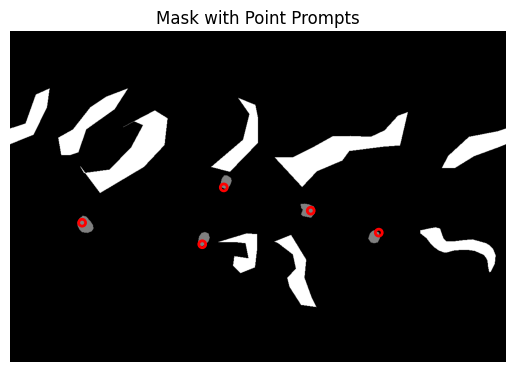

In [6]:
def plot_mask_with_points(mask, point_prompts, color='red', radius=8):
    """
    Plot a mask with point prompts as circles.

    Parameters:
      mask: numpy.ndarray or torch.Tensor, shape [H, W]
      point_prompts: tuple (points, labels), points shape [N, 1, 2] or [N, 2]
      color: str, color for the circles
      radius: int, radius of the circles
    """
    if isinstance(mask, torch.Tensor):
        mask = mask.cpu().numpy()
    points = point_prompts[0]
    if points.ndim == 3:
        points = points.squeeze(1)
    points = points.cpu().numpy()
    plt.figure()
    plt.imshow(mask, cmap='gray')
    for x, y in points:
        circle = plt.Circle((x,y), radius, color=color, fill=False, linewidth=2)
        plt.gca().add_patch(circle)
    plt.title("Mask with Point Prompts")
    plt.axis('off')
    plt.show()

plot_mask_with_points(gt_mask, tc_point_prompts)

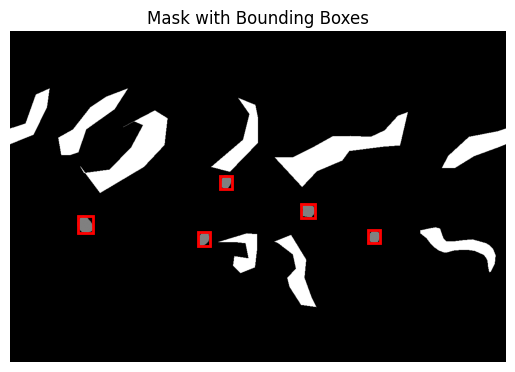

In [63]:
def plot_mask_with_bbox(mask, bbox_prompts, color='red'):
    """
    Plot a mask with bounding boxes.

    Parameters:
      mask: numpy.ndarray or torch.Tensor, shape [H, W]
      bbox_prompts: torch.Tensor, shape [N, 1, 4] or [N, 4]
      color: str, color for the bounding boxes
    """
    if isinstance(mask, torch.Tensor):
        mask = mask.cpu().numpy()
    plt.figure()
    plt.imshow(mask, cmap='gray')
    # Handle bbox_prompts shape
    bboxes = bbox_prompts.squeeze(1).cpu().numpy() if bbox_prompts.ndim == 3 else bbox_prompts.cpu().numpy()
    for bbox in bboxes:
        x1, y1, x2, y2 = bbox
        width = x2 - x1
        height = y2 - y1
        rect = plt.Rectangle((x1, y1), width, height, linewidth=2, edgecolor=color, facecolor='none')
        plt.gca().add_patch(rect)
    plt.title("Mask with Bounding Boxes")
    plt.axis('off')
    plt.show()

plot_mask_with_bbox(gt_mask, tc_bbox_prompts)

In [116]:
tc_objs = []
ar_objs = []
for i in range(len(train_dataset)):
    try:
        tc_objs.append(len(train_dataset[i]['tc_point_prompts'][1]))
    except:
        tc_objs.append(0)
        
    try:
        ar_objs.append(len(train_dataset[i]['ar_point_prompts'][1]))
    except:
        ar_objs.append(0)
        
        
